# 02 — Do individual channels care about direction?

**Goal of this notebook:** establish the basic neural phenomenon *by eye*, before any
machine learning gets involved.

A decoder is a powerful thing, and a powerful thing will find structure whether or not
the structure is real. If a bug in our labels or our alignment produces above-chance
decoding in notebook 03, we want to already know what the raw signal looks like so we can
tell the difference. So: no classifiers here. Just averages.

The claim we are trying to see directly is:

> **Individual channels fire differently depending on which direction the participant
> intends to move — and they do so during the delay, before any movement.**

---

## Why would motor cortex do that?

The foundational result is **Georgopoulos et al. (1982)**: neurons in primary motor cortex
fire at a rate that varies smoothly with the *direction* of a reach. Each neuron has a
**preferred direction** where it fires fastest, and its rate falls off roughly as the
cosine of the angle away from it:

$$r(\theta) = b_0 + b_1 \cos(\theta - \theta_{pref})$$

No single neuron specifies the movement — each is broadly tuned and noisy — but the
*population* jointly does. That is the entire premise of a motor BCI, and it is the
premise our decoder will exploit in notebook 03.

The twist that makes this dataset interesting: much of this directional tuning appears
**during preparation**, while the participant is holding still and waiting for the go cue.
On the modern *dynamical-systems* account, that preparatory activity is not a weak copy
of the movement command; it is the population being set to an initial state from which
the movement-generating dynamics will unroll once released. Preparation and execution can
therefore look quite different at the population level — which is exactly the question
notebook 04 asks.

## What is a PSTH?

A **peri-stimulus time histogram**: take all trials of one condition, align them to an
event (here, target onset at `t = 0`), and average the firing rate at each time point.
Single trials are far too noisy to read; averaging across ~30 trials of the same direction
exposes the systematic part.

We will plot one PSTH per direction per channel. If direction matters to a channel, its
eight traces should separate after `t = 0`, and overlap before it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src import plotting
from src.data_loading import load_trial_data
from src.preprocessing import (direction_labels, pick_feature, select_trials,
                               check_class_balance, to_hz)

np.random.seed(config.RANDOM_STATE)
plotting.use_house_style()
config.ensure_output_dirs()

td = load_trial_data(config.PARTICIPANT, config.ALIGNMENT, config.FIGURE,
                     config.candidate_data_dirs())
print(td)

TrialData(T16/delay: 385 trials x 150 bins x 61 chans, bin=20 ms, t=-1000..1980 ms)


## 1. The trial set

We use the same selection the decoder will use in notebook 03, so that what we see here
is what the decoder sees: **go trials only**, with an instructed delay of at least
`MIN_DELAY_S`, and no NaNs.

The selection prints a report rather than quietly filtering — if a future participant's
file loses half its trials to some criterion, that should be impossible to miss.

In [2]:
features = pick_feature(td, config.FEATURE_TYPE)          # (trials, bins, channels)
keep, report = select_trials(features, td.delay, td.no_go,
                             config.MIN_DELAY_S, config.GO_TRIALS_ONLY)
print(report)

labels_all, centres = direction_labels(td.target, td.start, config.N_DIRECTIONS)

X = features[keep]                    # (trials, bins, channels), counts per bin
y = labels_all[keep]
blocks = td.block[keep]
t_ms = td.t_ms

counts = check_class_balance(y, config.N_DIRECTIONS, config.MIN_TRIALS_PER_DIRECTION)
print(f"\ntrials per direction: {counts.tolist()}")

# Go-cue times present in this trial set, for the figure annotations.
go_cue_times_ms = sorted((np.unique(td.delay[keep]) * 1000).tolist())
print(f"go cue times in this trial set: {go_cue_times_ms} ms")

Trial selection
  starting trials              : 385
  dropped, non-finite features : 0
  dropped, non-finite delay    : 0
  dropped, delay < 0.8 s        : 0
  dropped, no-go trials        : 121
  --> kept                     : 264

trials per direction: [29, 37, 28, 36, 30, 29, 37, 38]
go cue times in this trial set: [1000.0, 1500.0] ms


> Note for T16: the instructed delays here are 1.0 s and 1.5 s, so the `MIN_DELAY_S = 0.8`
> filter removes nothing. It is not redundant in general — participant T5's delays run
> from 0.2 s to 1.4 s, and there the same line does real work.

## 2. From counts to firing rates

Everything from here on is in **Hz**, because a firing rate is a quantity we can sanity-
check against physiology (cortical neurons at 5–30 Hz: plausible; at 500 Hz: a bug).

In [3]:
X_hz = to_hz(X, td.bin_s)      # counts/bin -> Hz
print(f"X_hz: {X_hz.shape}  (trials, bins, channels)")
print(f"grand mean firing rate: {X_hz.mean():.2f} Hz")

X_hz: (264, 150, 61)  (trials, bins, channels)
grand mean firing rate: 8.31 Hz


## 3. Population overview

First, the simplest possible view: average across *all* channels and *all* trials. This
throws away everything direction-specific — every direction is averaged together — so it
shows only the population's overall response to the task's events.

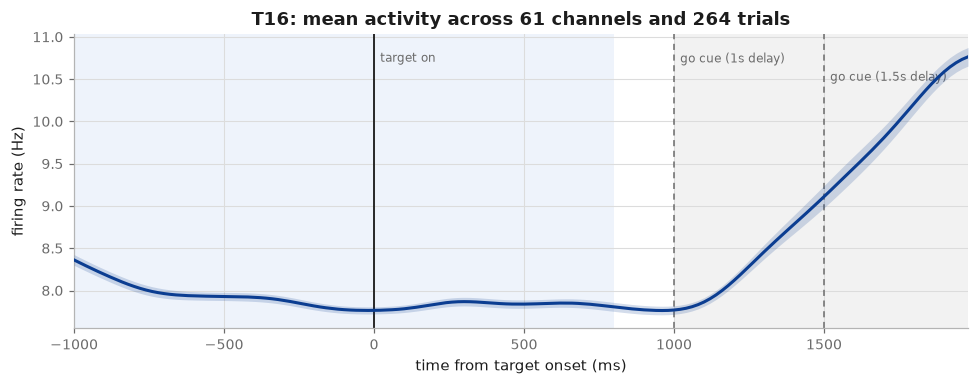

In [4]:
pop_by_trial = X_hz.mean(axis=2)                 # (trials, bins): mean over channels
pop_mean = pop_by_trial.mean(axis=0)
pop_sem = pop_by_trial.std(axis=0, ddof=1) / np.sqrt(pop_by_trial.shape[0])

fig, ax = plt.subplots(figsize=(9, 3.6))
plotting.plot_population_overview(
    t_ms, pop_mean, pop_sem,
    go_cue_times_ms=go_cue_times_ms,
    prep_window_ms=config.PREP_WINDOW_MS,
    title=f"{config.PARTICIPANT}: mean activity across {X.shape[2]} channels "
          f"and {X.shape[0]} trials",
    ax=ax,
)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "population_overview.png", bbox_inches="tight")
plt.show()

Whatever this curve does, note what it **cannot** tell us: since all eight directions are
pooled, a change here reflects general engagement with the task — arousal, attention,
visual response, movement effort — not directional intent. A flat curve would not disprove
our hypothesis, and a large bump would not support it. That is exactly why we now split by
direction.

## 4. Which channels are direction-tuned?

To pick example channels honestly, we need a criterion fixed in advance rather than
"whichever ones look nicest". We use a **one-way ANOVA**: for each channel, take its mean
firing rate over a preparatory window on each trial, and ask whether that mean differs
across the eight direction groups. The F-statistic is the ratio

$$F = \frac{\text{variance between direction groups}}{\text{variance within direction groups}}$$

so F ≈ 1 means "the differences between directions are no bigger than the trial-to-trial
noise", and large F means the direction genuinely matters to this channel.

The crucial control is to run the **identical test on a baseline window before the target
appears**. At that point the participant does not yet know which direction to prepare, so
no channel can possibly be tuned. Whatever F-values we get there are the noise floor —
and with 61 channels tested at p < 0.05, we should expect around 3 false positives by
chance alone.

In [5]:
PREP_WINDOW = (400.0, 800.0)      # inside the delay, clear of the go cue
BASE_WINDOW = (-800.0, -200.0)    # before the target appears: nothing to be tuned to

def window_means(x_hz, t, window):
    # Mean firing rate within a time window -> (trials, channels)
    sel = (t >= window[0]) & (t <= window[1])
    return x_hz[:, sel, :].mean(axis=1)

def anova_f(activity, y, n_groups):
    # One-way ANOVA F per channel, across the direction groups
    return np.array([
        stats.f_oneway(*[activity[y == g, ch] for g in range(n_groups)]).statistic
        for ch in range(activity.shape[1])
    ])

prep_act = window_means(X_hz, t_ms, PREP_WINDOW)
base_act = window_means(X_hz, t_ms, BASE_WINDOW)

F_prep = anova_f(prep_act, y, config.N_DIRECTIONS)
F_base = anova_f(base_act, y, config.N_DIRECTIONS)

# p < 0.05 threshold for this design
df_between = config.N_DIRECTIONS - 1
df_within = len(y) - config.N_DIRECTIONS
f_crit = stats.f.ppf(0.95, df_between, df_within)

print(f"F threshold for p<0.05 (df={df_between},{df_within}): {f_crit:.2f}")
print(f"expected false positives among {X.shape[2]} channels at p<0.05: "
      f"~{0.05 * X.shape[2]:.1f}\n")
print(f"preparatory window {PREP_WINDOW[0]:.0f}..{PREP_WINDOW[1]:.0f} ms : "
      f"{int((F_prep > f_crit).sum())}/{X.shape[2]} channels significant   "
      f"(max F = {F_prep.max():.1f})")
print(f"baseline window   {BASE_WINDOW[0]:.0f}..{BASE_WINDOW[1]:.0f} ms : "
      f"{int((F_base > f_crit).sum())}/{X.shape[2]} channels significant   "
      f"(max F = {F_base.max():.1f})")

F threshold for p<0.05 (df=7,256): 2.05
expected false positives among 61 channels at p<0.05: ~3.1

preparatory window 400..800 ms : 34/61 channels significant   (max F = 17.1)
baseline window   -800..-200 ms : 6/61 channels significant   (max F = 3.5)


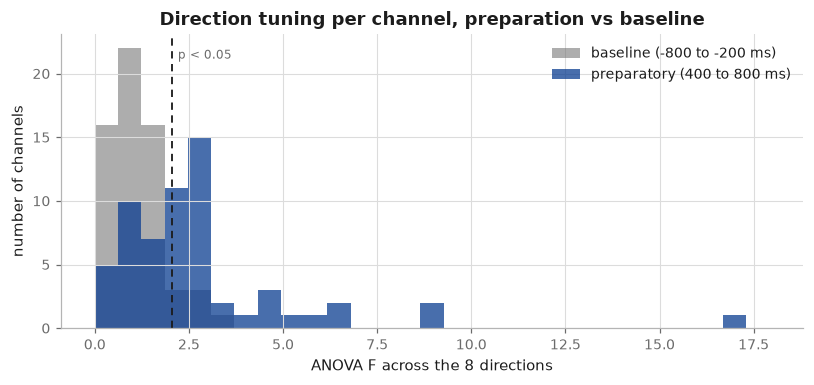

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
bins = np.linspace(0, max(F_prep.max(), F_base.max()) * 1.05, 30)
ax.hist(F_base, bins=bins, color="#6b6b6b", alpha=0.55, lw=0,
        label=f"baseline ({BASE_WINDOW[0]:.0f} to {BASE_WINDOW[1]:.0f} ms)")
ax.hist(F_prep, bins=bins, color=plotting.ACCENT, alpha=0.75, lw=0,
        label=f"preparatory ({PREP_WINDOW[0]:.0f} to {PREP_WINDOW[1]:.0f} ms)")
ax.axvline(f_crit, color=plotting.INK, lw=1.2, ls=(0, (4, 3)))
ax.annotate("p < 0.05", xy=(f_crit, 1.0), xycoords=("data", "axes fraction"),
            xytext=(4, -10), textcoords="offset points",
            fontsize=8, color=plotting.INK_MUTED, va="top")
ax.set_xlabel("ANOVA F across the 8 directions")
ax.set_ylabel("number of channels")
ax.set_title("Direction tuning per channel, preparation vs baseline")
ax.legend()
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "tuning_f_distribution.png", bbox_inches="tight")
plt.show()

## 5. Direction-conditioned PSTHs

Now the main figure. For the most strongly tuned channels, we plot mean firing rate over
time, one trace per direction.

What to look for:

- **Before `t = 0`:** the eight traces should sit on top of one another. The target has not
  appeared, so there is nothing for the channel to be tuned to. Separation here would mean
  something is wrong — a label leak, or trials not properly aligned.
- **After `t = 0`:** the traces should fan apart, and stay apart through the delay while
  the participant holds still.
- The traces are ordered around the colour wheel, so a cleanly tuned channel often shows
  its eight traces stacked roughly in angular order rather than jumbled.

In [7]:
N_EXAMPLES = 6
example_idx = np.argsort(F_prep)[::-1][:N_EXAMPLES]

# PSTH: mean over trials of each direction -> (channels, directions, bins)
psth = np.stack([
    np.stack([X_hz[y == d][:, :, ch].mean(axis=0) for d in range(config.N_DIRECTIONS)])
    for ch in example_idx
])
psth_sem = np.stack([
    np.stack([X_hz[y == d][:, :, ch].std(axis=0, ddof=1) / np.sqrt((y == d).sum())
              for d in range(config.N_DIRECTIONS)])
    for ch in example_idx
])

# Report the array (electrode) id, not just our column index.
example_electrodes = [int(td.keep_chans[i]) for i in example_idx]
print("example channels (column index -> electrode id, ANOVA F):")
for i, e in zip(example_idx, example_electrodes):
    print(f"  col {i:3d} -> electrode {e:3d}   F = {F_prep[i]:.1f}")

example channels (column index -> electrode id, ANOVA F):
  col   7 -> electrode 168   F = 17.1
  col  50 -> electrode 236   F = 9.1
  col  12 -> electrode 186   F = 8.9
  col  58 -> electrode 251   F = 6.4
  col  22 -> electrode 203   F = 6.2
  col   4 -> electrode 154   F = 5.6


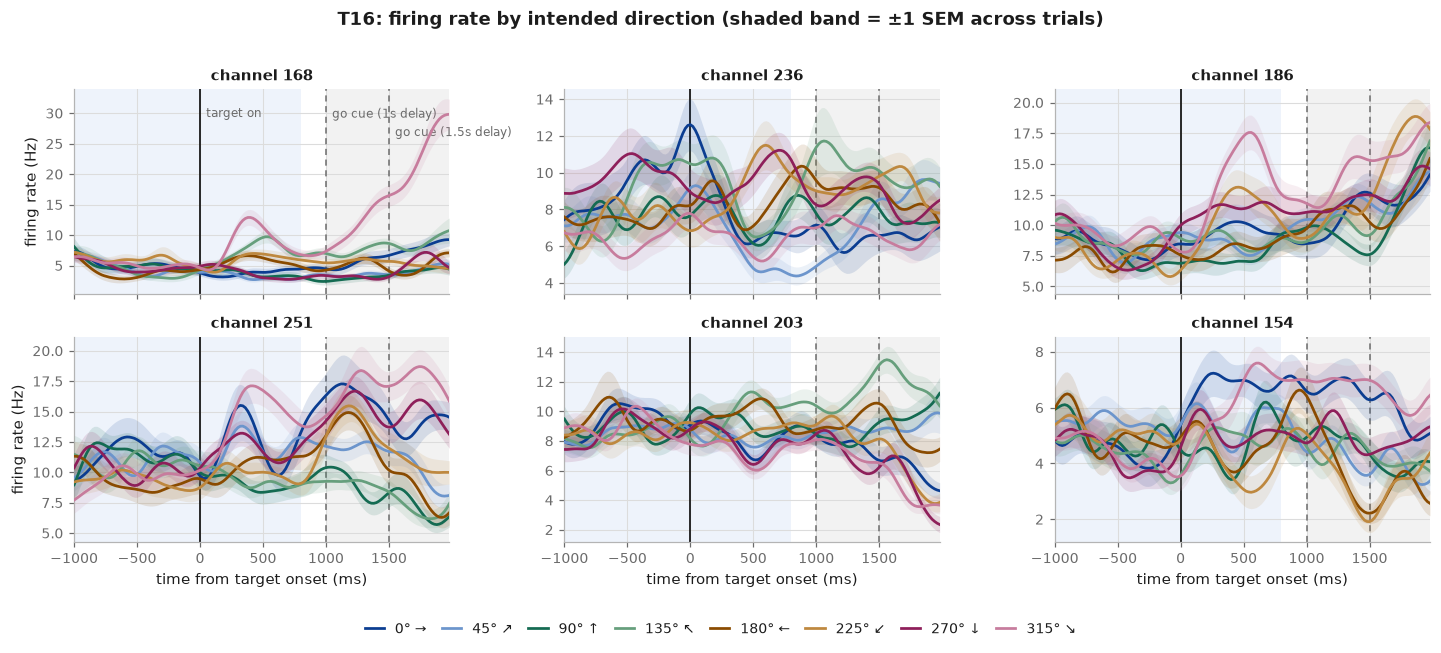

In [8]:
fig = plotting.plot_direction_psths(
    t_ms, psth, example_electrodes, centres,
    sem_by_dir=psth_sem,
    go_cue_times_ms=go_cue_times_ms,
    prep_window_ms=config.PREP_WINDOW_MS,
    suptitle=f"{config.PARTICIPANT}: firing rate by intended direction "
             f"(shaded band = ±1 SEM across trials)",
    ncols=3,
)
fig.savefig(config.FIGURES_DIR / "example_psths.png", bbox_inches="tight")
plt.show()

## 6. Tuning curves

The PSTHs show tuning unfolding over time. Collapsing the preparatory window to a single
number per direction gives the classic **tuning curve** — and on polar axes, direction is
encoded by *position*, so the shape is readable without relying on colour at all.

A channel with clean cosine tuning shows a smooth lobe pointing toward its preferred
direction. Real multi-unit channels are messier than the textbook picture: each electrode
pools several neurons with different preferred directions, which blurs the lobe.

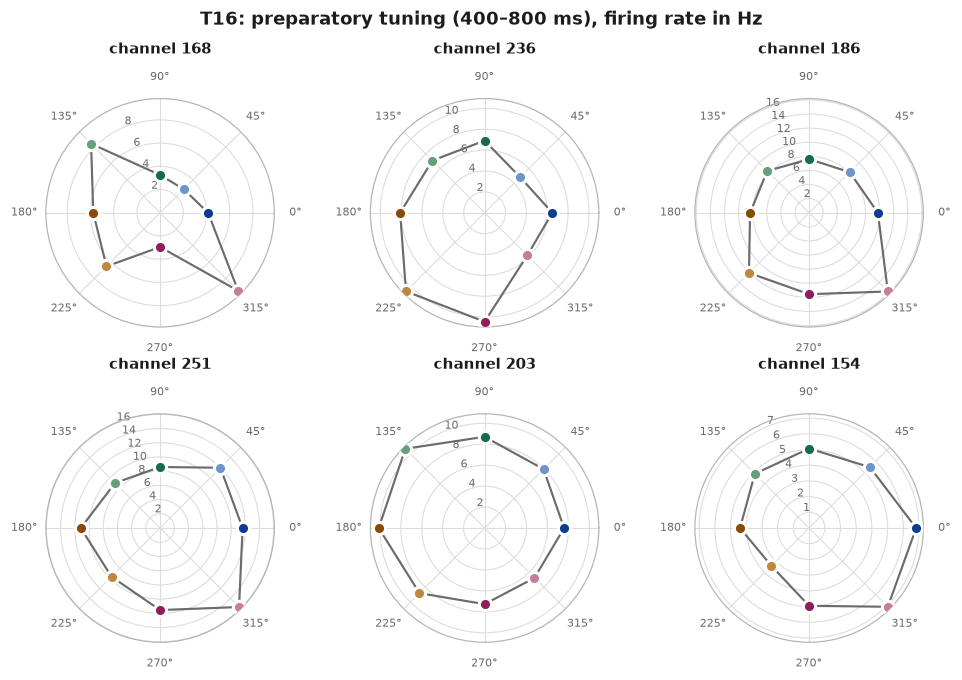

In [9]:
mean_by_dir = np.stack([
    np.stack([prep_act[y == d, ch].mean() for d in range(config.N_DIRECTIONS)])
    for ch in example_idx
])

fig = plotting.plot_polar_tuning(
    mean_by_dir, example_electrodes, centres,
    suptitle=f"{config.PARTICIPANT}: preparatory tuning "
             f"({PREP_WINDOW[0]:.0f}–{PREP_WINDOW[1]:.0f} ms), firing rate in Hz",
    ncols=3,
)
fig.savefig(config.FIGURES_DIR / "tuning_polar.png", bbox_inches="tight")
plt.show()

## 7. A first quantitative peek: the preferred direction of every channel

If the tuning is real and cosine-like, we can summarise each channel with a single vector:
sum the eight direction unit-vectors weighted by the channel's firing rate in each. The
angle of the resulting vector is the channel's **preferred direction**, and its length
(normalised) is a **modulation depth** — how strongly the channel discriminates direction
at all.

This is a compact way to ask a population-level question: do the preferred directions
cover the whole circle? If the array only encoded, say, leftward movements, an eight-way
decoder would be in trouble.

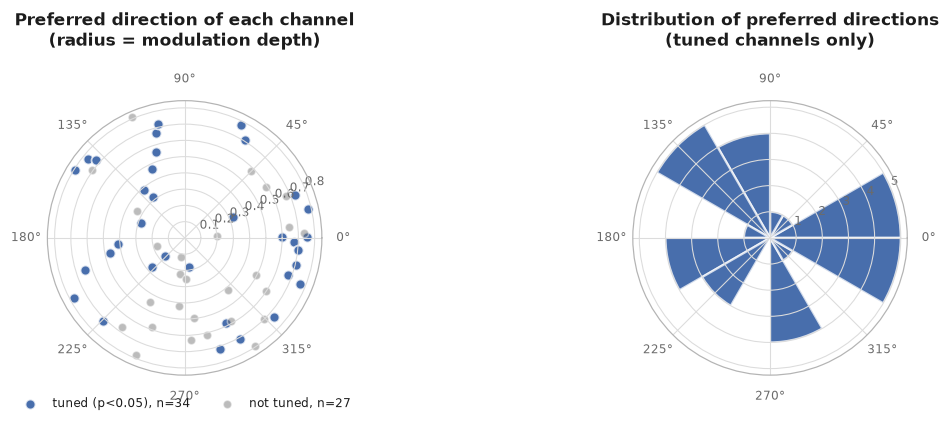

In [10]:
unit_vectors = np.stack([np.cos(centres), np.sin(centres)], axis=1)   # (8, 2)

all_by_dir = np.stack([prep_act[y == d].mean(axis=0)
                       for d in range(config.N_DIRECTIONS)])          # (8, channels)
centred = all_by_dir - all_by_dir.mean(axis=0, keepdims=True)
vectors = centred.T @ unit_vectors                                    # (channels, 2)

pref_dir = np.mod(np.arctan2(vectors[:, 1], vectors[:, 0]), 2 * np.pi)
modulation = np.linalg.norm(vectors, axis=1) / np.abs(centred).sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4),
                         subplot_kw={"projection": "polar"})
tuned = F_prep > f_crit

axes[0].scatter(pref_dir[tuned], modulation[tuned], s=42,
                color=plotting.ACCENT, alpha=0.75, edgecolor="white", lw=1.2,
                label=f"tuned (p<0.05), n={int(tuned.sum())}")
axes[0].scatter(pref_dir[~tuned], modulation[~tuned], s=30,
                color=plotting.INK_MUTED, alpha=0.45, edgecolor="white", lw=1.0,
                label=f"not tuned, n={int((~tuned).sum())}")
axes[0].set_title("Preferred direction of each channel\n(radius = modulation depth)",
                  fontsize=11, pad=18)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), fontsize=8, ncol=2)

edges = np.linspace(0, 2 * np.pi, 13)
hist, _ = np.histogram(pref_dir[tuned], bins=edges)
axes[1].bar(edges[:-1], hist, width=np.diff(edges), align="edge",
            color=plotting.ACCENT, alpha=0.75, edgecolor="white", lw=1.5)
axes[1].set_title("Distribution of preferred directions\n(tuned channels only)",
                  fontsize=11, pad=18)

for ax in axes:
    ax.grid(color=plotting.GRID, lw=0.7)
    ax.tick_params(labelsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "preferred_directions.png", bbox_inches="tight")
plt.show()

In [11]:
summary = pd.DataFrame({
    "electrode": td.keep_chans.astype(int),
    "mean_rate_hz": X_hz.mean(axis=(0, 1)).round(2),
    "F_preparatory": F_prep.round(2),
    "F_baseline": F_base.round(2),
    "tuned_p05": tuned,
    "preferred_direction_deg": np.degrees(pref_dir).round(1),
    "modulation_depth": modulation.round(4),
}).sort_values("F_preparatory", ascending=False)

out = config.TABLES_DIR / "channel_tuning.csv"
summary.to_csv(out, index=False)
print(f"saved -> {out}")
summary.head(12)

saved -> C:\Users\gilad\Intracortical_project\intracortical-prep-decoding\results\tables\channel_tuning.csv


,electrode,mean_rate_hz,F_preparatory,F_baseline,tuned_p05,preferred_direction_deg,modulation_depth
7,168,5.71,17.06,1.83,True,221.7,0.2708
50,236,8.07,9.09,2.62,True,225.4,0.7182
12,186,10.10,8.87,0.95,True,287.9,0.7151
58,251,11.38,6.35,1.39,True,318.5,0.7337
22,203,8.48,6.24,0.84,True,148.2,0.7934
4,154,4.93,5.62,0.92,True,0.3,0.7558
1,145,4.71,5.11,1.52,True,357.7,0.6728
17,197,6.36,4.54,1.86,True,208.3,0.7752
0,137,8.38,4.41,0.25,True,346.3,0.7026
55,243,3.35,4.38,1.13,True,128.1,0.3180


## What we established

Before touching a classifier, we have seen the phenomenon in the raw averages:

- A substantial fraction of channels distinguish the eight directions **during the delay**,
  far more than the ~3/61 the baseline window says we should get by chance.
- The separation appears **after target onset and before movement** — which is the
  necessary condition for our whole question.
- Preferred directions are spread around the circle rather than clustered on one axis,
  so an eight-way decoder has something to work with in every direction.

That last point is the bridge to notebook 03. No single channel here comes close to
specifying direction on its own — the traces overlap heavily and the tuning is broad. The
decoder's job is to combine all 61 weak, noisy, differently-tuned channels into one
population read-out.

---

## Now try this

1. **Check the noise floor honestly.** Re-run section 5 with `example_idx` set to the
   *least* tuned channels (`np.argsort(F_prep)[:6]`). Convince yourself that "eight
   overlapping traces" is what no tuning looks like — that is the comparison that makes
   the tuned panels meaningful.
2. **Move the window.** Set `PREP_WINDOW = (0, 200)` and re-run. Does tuning exist that
   early? Now remember the acausal σ = 100 ms smoothing before you answer — how much of
   any early effect could be leakage from later activity?
3. **Try the other feature.** Set `FEATURE_TYPE = "sbp"` in `config.py` and re-run. Are the
   same channels tuned? (Note the y-axis is no longer Hz — spike-band power is in arbitrary
   units, so the `to_hz` conversion is meaningless there. What should you change?)
4. **Look at the no-go trials.** Set `GO_TRIALS_ONLY = False` and compare. On no-go trials
   the movement is never released — does the preparatory separation still appear?